In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    f1_score, precision_score, recall_score, roc_curve
)
from imblearn.over_sampling import SMOTE

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [3]:
#loading processed splits
X_train_resampled = pd.read_csv("Data/X_train_resampled.csv")
y_train_resampled = pd.read_csv("Data/y_train_resampled.csv").squeeze()
X_val_scaled = pd.read_csv("Data/X_val_scaled.csv")
y_val = pd.read_csv("Data/y_val.csv").squeeze()
X_test_scaled = pd.read_csv("Data/X_test_scaled.csv")
y_test = pd.read_csv("Data/y_test.csv").squeeze()
print("Loaded preprocessed splits.")

Loaded preprocessed splits.


In [4]:
#Model tuning 
knn_param_grid = {
    'n_neighbors': [3, 5, 9, 15, 21],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn_base = KNeighborsClassifier()

knn_grid = GridSearchCV(
    knn_base,
    knn_param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

knn_grid.fit(X_train_resampled, y_train_resampled)

print(f"Best params: {knn_grid.best_params_}")
print(f"Best CV AUC: {knn_grid.best_score_:.4f}")

5208.27s - Error patching args (debugger not attached to subprocess).
Traceback (most recent call last):
  File "/Users/arsshbajpai/Library/Python/3.9/lib/python/site-packages/debugpy/_vendored/pydevd/_pydev_bundle/pydev_monkey.py", line 541, in patch_args
    new_args.append(_get_python_c_args(host, port, code, unquoted_args, SetupHolder.setup))
  File "/Users/arsshbajpai/Library/Python/3.9/lib/python/site-packages/debugpy/_vendored/pydevd/_pydev_bundle/pydev_monkey.py", line 193, in _get_python_c_args
    if "__future__" in code:
TypeError: a bytes-like object is required, not 'str'


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}
Best CV AUC: 0.9592


In [6]:
# Validation results
knn_best = knn_grid.best_estimator_
knn_val_preds = knn_best.predict(X_val_scaled)
knn_val_probs = knn_best.predict_proba(X_val_scaled)[:, 1]

print("=== KNN — Validation Set Results ===\n")
print(classification_report(y_val, knn_val_preds, target_names=['No HD', 'Heart Disease']))
print(f"AUC-ROC:   {roc_auc_score(y_val, knn_val_probs):.4f}")
print(f"F1:        {f1_score(y_val, knn_val_preds):.4f}")
print(f"Precision: {precision_score(y_val, knn_val_preds):.4f}")
print(f"Recall:    {recall_score(y_val, knn_val_preds):.4f}")
print(f"Best Params: {knn_grid.best_params_}")

print("\n--- Threshold Tuning ---\n")
for threshold in [0.2, 0.3, 0.4]:
    preds_tuned = (knn_val_probs >= threshold).astype(int)
    print(f"=== Threshold = {threshold} ===")
    print(classification_report(y_val, preds_tuned, target_names=['No HD', 'Heart Disease']))
    print(f"Recall:    {recall_score(y_val, preds_tuned):.4f}")
    print(f"Precision: {precision_score(y_val, preds_tuned):.4f}")
    print(f"F1:        {f1_score(y_val, preds_tuned):.4f}")
    print()

=== KNN — Validation Set Results ===

               precision    recall  f1-score   support

        No HD       0.94      0.80      0.86     30910
Heart Disease       0.24      0.55      0.33      3557

     accuracy                           0.77     34467
    macro avg       0.59      0.67      0.60     34467
 weighted avg       0.87      0.77      0.81     34467

AUC-ROC:   0.7430
F1:        0.3346
Precision: 0.2406
Recall:    0.5496
Best Params: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}

--- Threshold Tuning ---

=== Threshold = 0.2 ===
               precision    recall  f1-score   support

        No HD       0.96      0.66      0.78     30910
Heart Disease       0.20      0.74      0.31      3557

     accuracy                           0.67     34467
    macro avg       0.58      0.70      0.55     34467
 weighted avg       0.88      0.67      0.73     34467

Recall:    0.7380
Precision: 0.1985
F1:        0.3128

=== Threshold = 0.3 ===
               p

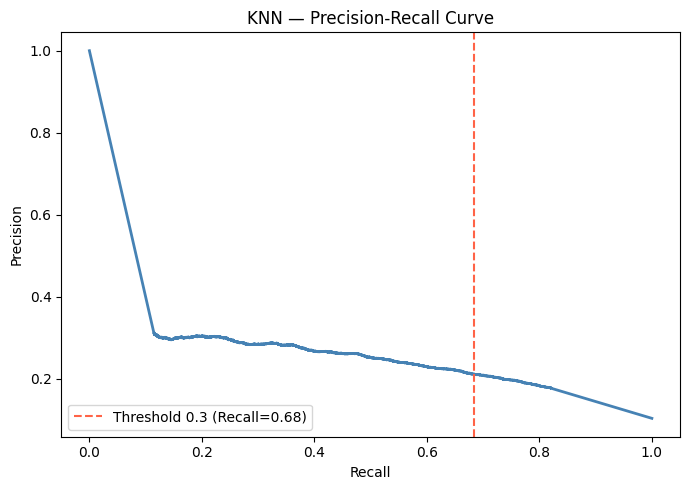

In [7]:
# Precision-Recall Curve
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_val, knn_val_probs)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recalls, precisions, color='steelblue', lw=2)
ax.axvline(x=0.6834, color='tomato', linestyle='--', label='Threshold 0.3 (Recall=0.68)')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('KNN — Precision-Recall Curve')
ax.legend()
plt.tight_layout()
plt.show()

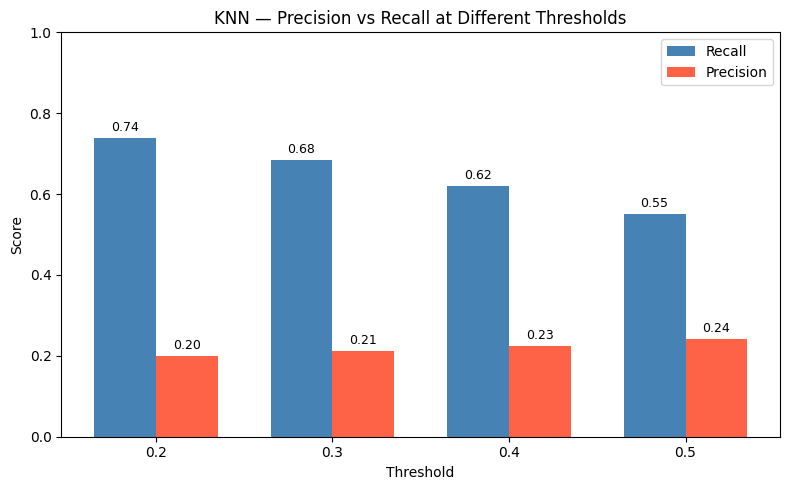

In [8]:
# Threshold Comparison Bar Chart
thresholds_list = [0.2, 0.3, 0.4, 0.5]
recalls_list = [0.7380, 0.6834, 0.6202, 0.5496]
precisions_list = [0.1985, 0.2112, 0.2252, 0.2406]

x = np.arange(len(thresholds_list))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, recalls_list, width, label='Recall', color='steelblue')
bars2 = ax.bar(x + width/2, precisions_list, width, label='Precision', color='tomato')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('KNN — Precision vs Recall at Different Thresholds')
ax.set_xticks(x)
ax.set_xticklabels([str(t) for t in thresholds_list])
ax.legend()
ax.set_ylim(0, 1)
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

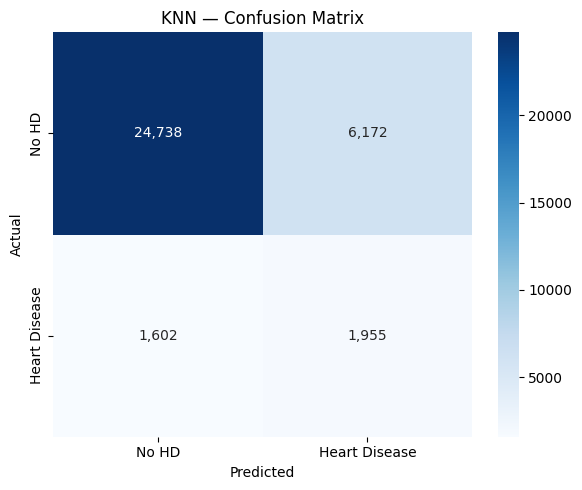

In [ ]:
#Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_val, knn_val_preds)
sns.heatmap(cm, annot=True, fmt=',', cmap='Blues', ax=ax,
            xticklabels=['No HD', 'Heart Disease'],
            yticklabels=['No HD', 'Heart Disease'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('KNN — Confusion Matrix')
plt.tight_layout()
plt.show()

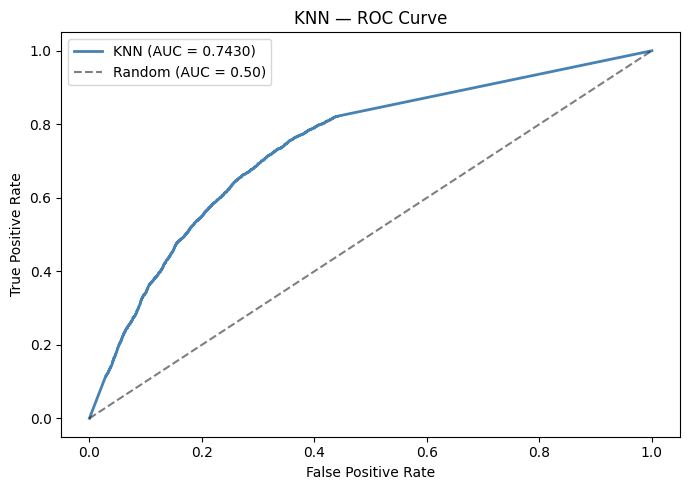

In [ ]:
#ROC Curve
fig, ax = plt.subplots(figsize=(7, 5))
knn_fpr, knn_tpr, _ = roc_curve(y_val, knn_val_probs)
knn_auc = roc_auc_score(y_val, knn_val_probs)
ax.plot(knn_fpr, knn_tpr, color='steelblue', lw=2, label=f'KNN (AUC = {knn_auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random (AUC = 0.50)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('KNN — ROC Curve')
ax.legend()
plt.tight_layout()
plt.show()